In [2]:
# PDF Requirement 1: Data Cleaning Pipeline
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Load Netflix dataset (Using a new, working URL)
print("Loading Netflix Dataset...")
url = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/netflix_titles.csv" #
df = pd.read_csv(url)

# 2. Identify and handle missing values
print("Cleaning Data...")
df['director'] = df['director'].fillna('Unknown Director')
df['cast'] = df['cast'].fillna('Unknown Cast')
df['country'] = df['country'].fillna('Unknown Country')

# Remove rows where crucial data (date or rating) is missing
df = df.dropna(subset=['date_added', 'rating'])

# 3. Create derived features for analysis
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print(f"Data Cleaned Successfully! Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
display(df.head())

Loading Netflix Dataset...
Cleaning Data...
Data Cleaned Successfully! Total Rows: 6214, Total Columns: 14


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,2019,9
1,80117401,Movie,Jandino: Whatever it Takes,Unknown Director,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,2016,9
2,70234439,TV Show,Transformers Prime,Unknown Director,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",2018,9
3,80058654,TV Show,Transformers: Robots in Disguise,Unknown Director,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,2018,9
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,2017,9


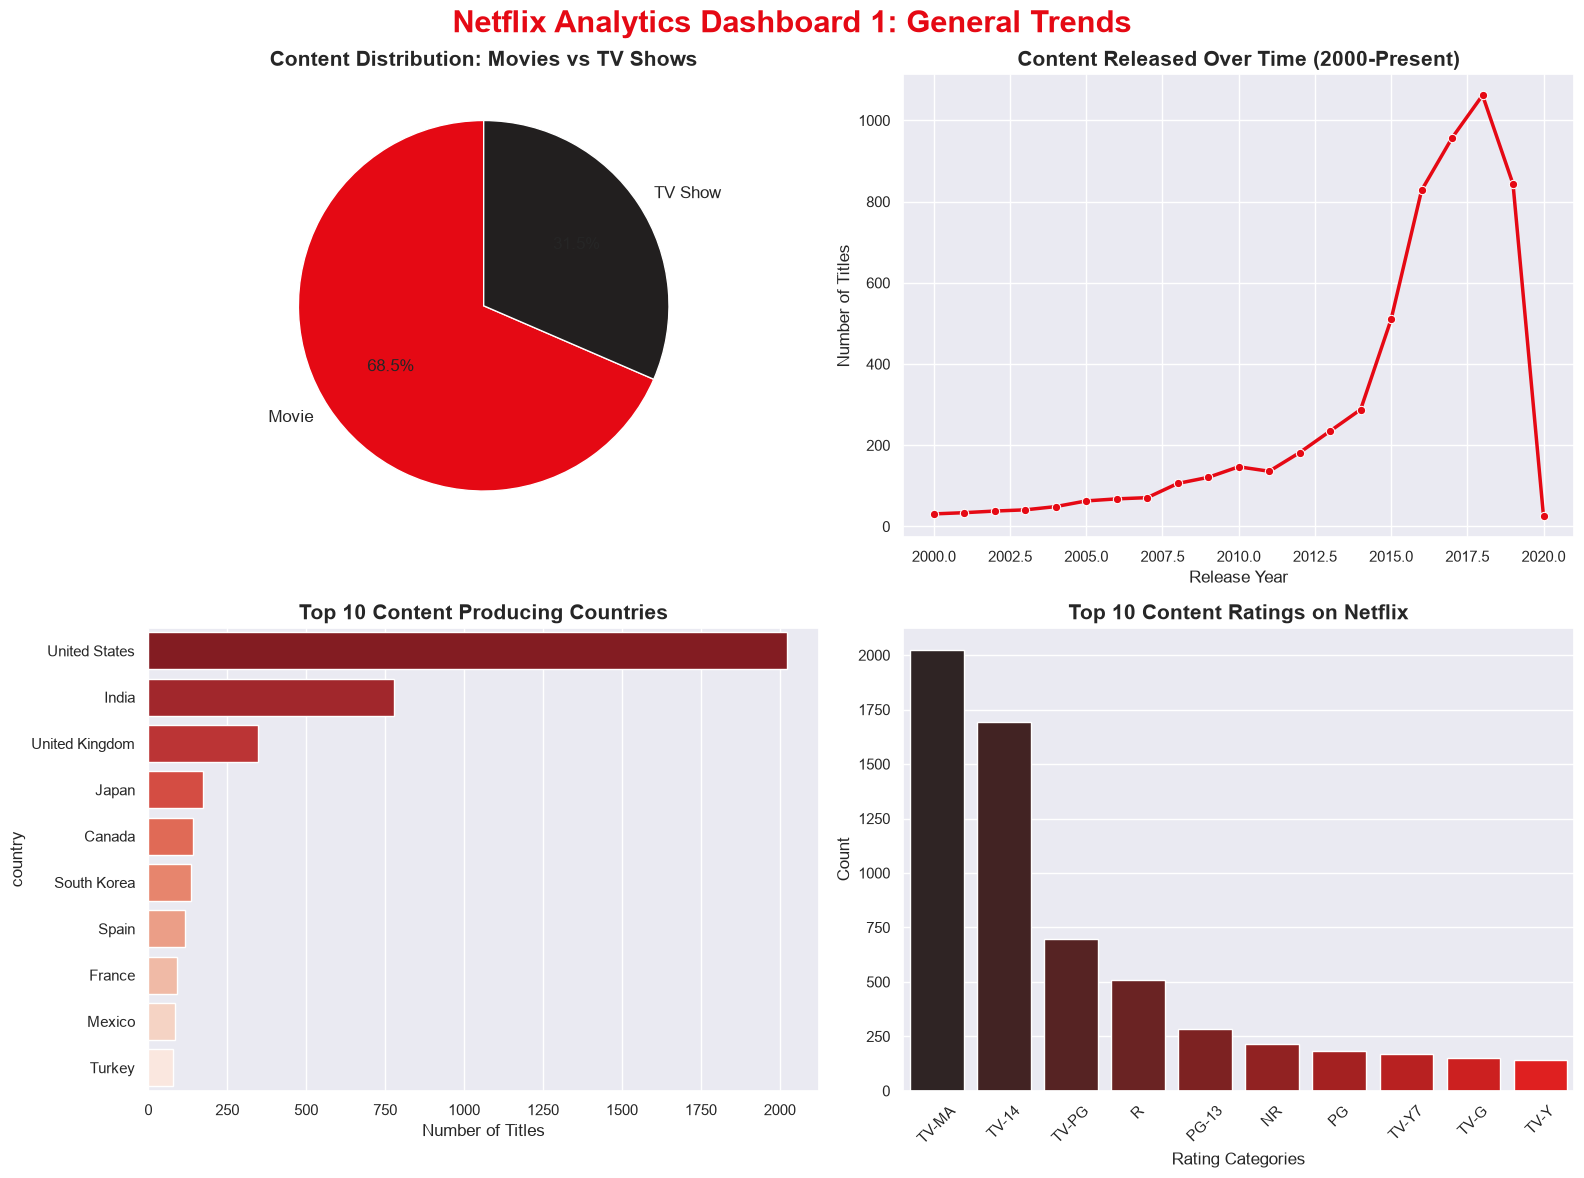

--- KEY BUSINESS INSIGHTS ---
1. Movies heavily dominate the Netflix platform (almost double the TV Shows).
2. There was a massive surge in content production between 2015 and 2019.
3. The United States is the largest content creator, with India at a strong second place.
4. TV-MA (Mature Audience) is the most common rating, indicating Netflix targets adult demographics more than kids.


In [ ]:
# PDF Requirement 2 & 3: EDA & Visualizations Dashboard
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style of our dashboard
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create a 2x2 grid for our dashboard
fig, axes = plt.subplots(2, 2)
fig.suptitle('Netflix Analytics Dashboard 1: General Trends', fontsize=22, fontweight='bold', color='#E50914')

# Chart 1: Pie Chart (Content count by type)
type_counts = df['type'].value_counts()
axes[0, 0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#E50914', '#221F1F'], startangle=90, textprops={'fontsize': 12})
axes[0, 0].set_title('Content Distribution: Movies vs TV Shows', fontsize=15, fontweight='bold')

# Chart 2: Line Chart (Release year trends)
recent_years = df[df['release_year'] >= 2000]
year_counts = recent_years['release_year'].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, ax=axes[0, 1], color='#E50914', marker='o', linewidth=2.5)
axes[0, 1].set_title('Content Released Over Time (2000-Present)', fontsize=15, fontweight='bold')
axes[0, 1].set_xlabel('Release Year', fontsize=12)
axes[0, 1].set_ylabel('Number of Titles', fontsize=12)

# Chart 3: Bar Chart (Content by top 10 countries)
top_countries = df[df['country'] != 'Unknown Country']['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1, 0], palette='Reds_r')
axes[1, 0].set_title('Top 10 Content Producing Countries', fontsize=15, fontweight='bold')
axes[1, 0].set_xlabel('Number of Titles', fontsize=12)

# Chart 4: Rating Distribution
top_ratings = df['rating'].value_counts().head(10).index
sns.countplot(data=df, x='rating', order=top_ratings, ax=axes[1, 1], palette='dark:red')
axes[1, 1].set_title('Top 10 Content Ratings on Netflix', fontsize=15, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_xlabel('Rating Categories', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)

# Adjust layout and show the dashboard
plt.tight_layout()
plt.show()

# Printing Key Insights for the Report
print("    KEY BUSINESS INSIGHTS    ")
print("1. Movies heavily dominate the Netflix platform (almost double the TV Shows).")
print("2. There was a massive surge in content production between 2015 and 2019.")
print("3. The United States is the largest content creator, with India at a strong second place.")
print("4. TV-MA (Mature Audience) is the most common rating, indicating Netflix targets adult demographics more than kids.")

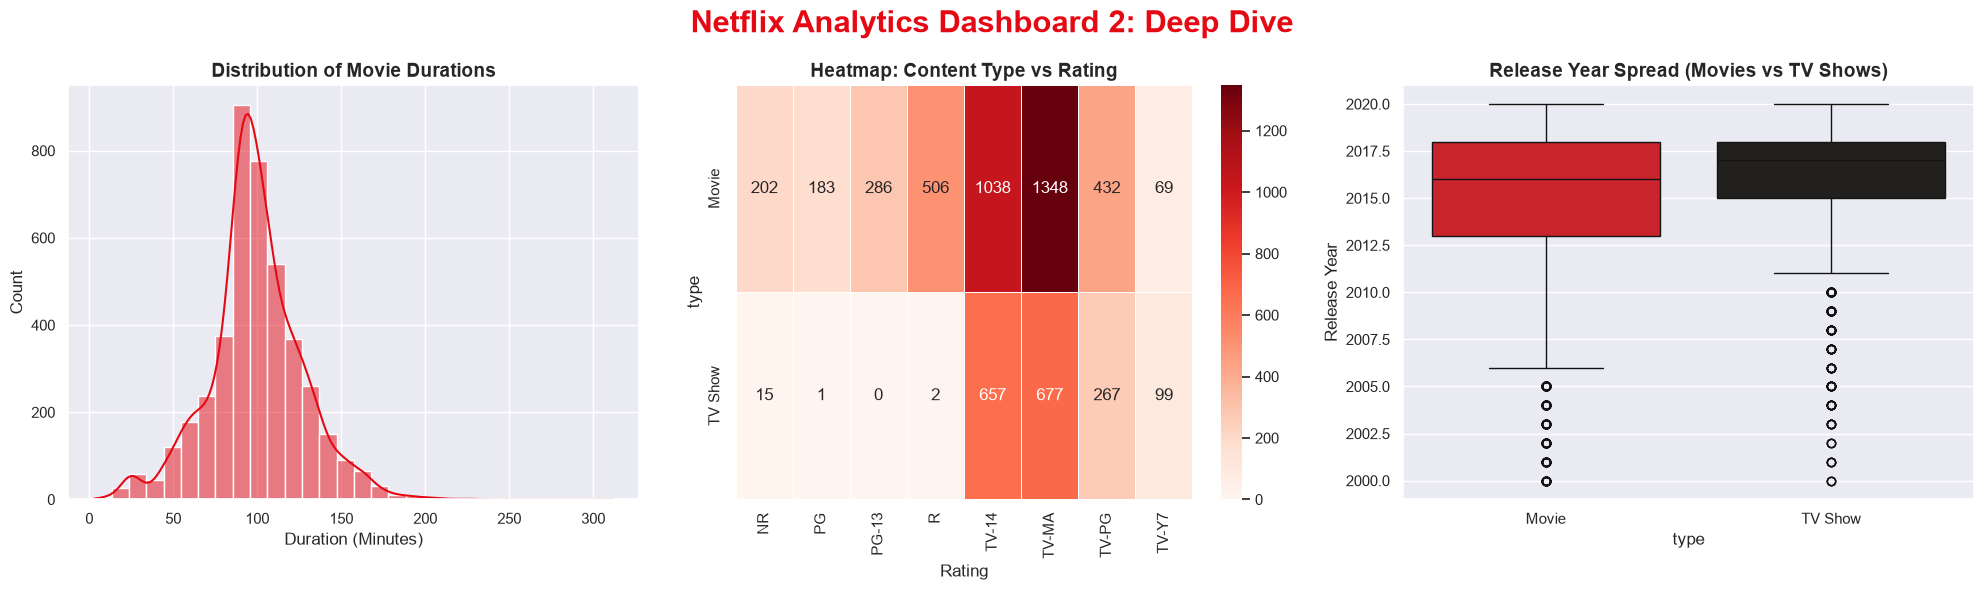

--- FINAL EXECUTIVE REPORT ---
1. Movie Duration: Most Netflix movies are between 90 to 110 minutes long (Histogram).
2. Rating Strategy: The Heatmap reveals TV-MA is the dominant rating for BOTH Movies and TV Shows.
3. Focus Shift: The Box Plot indicates Netflix started aggressively pushing TV Shows slightly later than Movies.
RECOMMENDATION: Continue investing heavily in TV-MA content, as it drives the most volume.


In [ ]:
# PDF Requirement 4: Advanced Visualizations (Histogram, Heatmap, Boxplot)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Netflix Analytics Dashboard 2: Deep Dive', fontsize=22, fontweight='bold', color='#E50914')

# Chart 5: Histogram (Duration distribution for Movies)
movies_df = df[df['type'] == 'Movie'].copy()
# Extracting integer minutes from the 'duration' string (e.g., '90 min' -> 90)
movies_df['duration_mins'] = movies_df['duration'].astype(str).str.replace(' min', '').astype(float)
sns.histplot(data=movies_df, x='duration_mins', bins=30, kde=True, color='#E50914', ax=axes[0])
axes[0].set_title('Distribution of Movie Durations', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Duration (Minutes)', fontsize=12)

# Chart 6: Heatmap (Content Type vs Top Ratings)
top_ratings = df['rating'].value_counts().head(8).index
heatmap_data = pd.crosstab(df[df['rating'].isin(top_ratings)]['type'], df[df['rating'].isin(top_ratings)]['rating'])
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds', ax=axes[1], linewidths=.5)
axes[1].set_title('Heatmap: Content Type vs Rating', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rating', fontsize=12)

# Chart 7: Box Plot (Release Year Distribution)
sns.boxplot(data=df[df['release_year'] >= 2000], x='type', y='release_year', palette=['#E50914', '#221F1F'], ax=axes[2])
axes[2].set_title('Release Year Spread (Movies vs TV Shows)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Release Year', fontsize=12)

plt.tight_layout()
plt.show()

# Final Report for Stakeholders
print("    FINAL EXECUTIVE REPORT    ")
print("1. Movie Duration: Most Netflix movies are between 90 to 110 minutes long (Histogram).")
print("2. Rating Strategy: The Heatmap reveals TV-MA is the dominant rating for BOTH Movies and TV Shows.")
print("3. Focus Shift: The Box Plot indicates Netflix started aggressively pushing TV Shows slightly later than Movies.")
print("RECOMMENDATION: Continue investing heavily in TV-MA content, as it drives the most volume.")